In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
# Load preprocessed dataset
df = pd.read_csv("secondary_data_preprocessed.csv")

In [29]:
X = df.drop(columns=["class_encoded"], errors="ignore")
y = df["class_encoded"]

In [31]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Model & Parameter Tuning
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(dt, param_grid, cv=5)
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_split': [2, 5, 10]})

In [43]:
best_dt = grid_dt.best_estimator_
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}


In [45]:
# Evaluation
y_pred = best_dt.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7309833024118738
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.77      0.72      4850
           1       0.79      0.70      0.74      5930

    accuracy                           0.73     10780
   macro avg       0.73      0.73      0.73     10780
weighted avg       0.74      0.73      0.73     10780



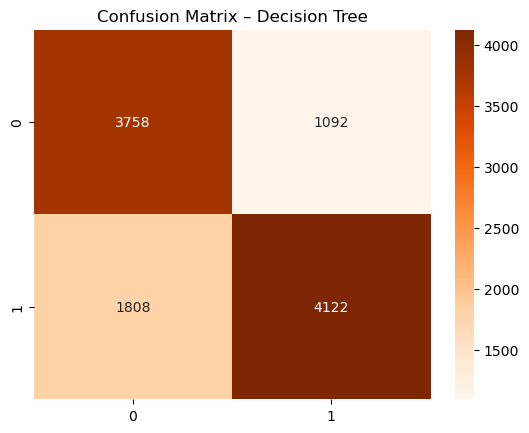

In [47]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Oranges")
plt.title("Confusion Matrix – Decision Tree")
plt.show()